In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: smokenandos
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:42<00:00, 17.1MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms

import torch.nn as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device available: ", device)

Device available:  cuda


In [3]:
image_path = []
labels = []


for i in os.listdir("/content/animal-faces/afhq/"):

  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):

    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      labels.append(label)
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")


data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])

print(data_df["labels"].unique())
data_df.head()



['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [4]:
train = data_df.sample(frac = 0.9)
test = data_df.drop(train.index)

val = test.sample(frac = 0.4)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(14517, 2)
(645, 2)
(968, 2)


In [5]:
test

,image_path,labels
58,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
79,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
158,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
196,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
200,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
...,...,...
16023,/content/animal-faces/afhq/train/wild/flickr_w...,wild
16026,/content/animal-faces/afhq/train/wild/flickr_w...,wild
16039,/content/animal-faces/afhq/train/wild/flickr_w...,wild
16052,/content/animal-faces/afhq/train/wild/pixabay_...,wild


In [6]:
label_encoder = LabelEncoder()

label_encoder.fit(data_df["labels"])


transform = transforms.Compose([
    transforms.Resize([132, 132]),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)

])

In [7]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe["labels"])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label


In [8]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)

In [9]:
train_dataset.__len__()

14517

In [10]:
train_dataset.__getitem__(9)

(tensor([[[0.3255, 0.3961, 0.4431,  ..., 0.5490, 0.5373, 0.5216],
          [0.3608, 0.3725, 0.4353,  ..., 0.5765, 0.5647, 0.5529],
          [0.2941, 0.3608, 0.4627,  ..., 0.6000, 0.5922, 0.5725],
          ...,
          [0.4353, 0.4392, 0.4510,  ..., 0.5765, 0.5686, 0.5373],
          [0.4627, 0.4275, 0.4078,  ..., 0.7725, 0.6863, 0.6118],
          [0.3961, 0.4392, 0.4392,  ..., 0.8314, 0.7294, 0.5725]],
 
         [[0.2471, 0.2824, 0.2471,  ..., 0.4588, 0.4431, 0.4314],
          [0.2588, 0.2471, 0.2549,  ..., 0.4745, 0.4627, 0.4471],
          [0.2118, 0.2588, 0.3059,  ..., 0.4902, 0.4784, 0.4627],
          ...,
          [0.3176, 0.3412, 0.3529,  ..., 0.0275, 0.0235, 0.0196],
          [0.3569, 0.3451, 0.3216,  ..., 0.0667, 0.0275, 0.0196],
          [0.3098, 0.3569, 0.3412,  ..., 0.0824, 0.0667, 0.0196]],
 
         [[0.1843, 0.1804, 0.1333,  ..., 0.2353, 0.2275, 0.2157],
          [0.1961, 0.1451, 0.1294,  ..., 0.2627, 0.2588, 0.2510],
          [0.1569, 0.1647, 0.1843,  ...,

In [11]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

In [12]:
label_encoder.inverse_transform([1])

array(['dog'], dtype=object)

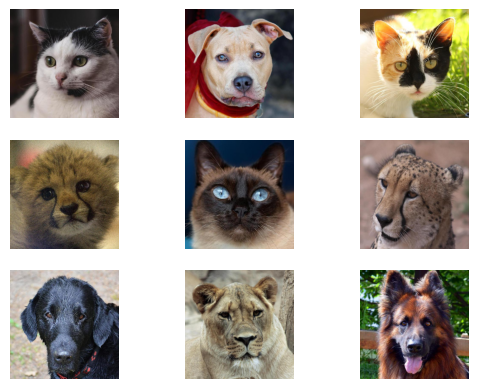

In [21]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

plt.show()

In [14]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10


In [15]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)


In [40]:
import torch.nn as nn
relu = nn.ReLU()

class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 4, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 4, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 4, padding = 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128 * 15 * 15), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) # 32, 127, 127. Convolution doesn't change the size
    x = self.pooling(x) # 32, 63, 63
    x = self.relu(x) #

    x = self.conv2(x) # 63, 63, 63
    x = self.pooling(x) # 63, 32, 32
    x = self.relu(x)

    x = self.conv3(x) # 127, 32, 32
    x = self.pooling(x) # 127, 15, 15
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x



In [41]:
import torch.nn as nn

model = Net().to(device)

In [42]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 127, 127]           1,568
         MaxPool2d-2           [-1, 32, 63, 63]               0
              ReLU-3           [-1, 32, 63, 63]               0
            Conv2d-4           [-1, 64, 62, 62]          32,832
         MaxPool2d-5           [-1, 64, 31, 31]               0
              ReLU-6           [-1, 64, 31, 31]               0
            Conv2d-7          [-1, 128, 30, 30]         131,200
         MaxPool2d-8          [-1, 128, 15, 15]               0
              ReLU-9          [-1, 128, 15, 15]               0
          Flatten-10                [-1, 28800]               0
           Linear-11                  [-1, 128]       3,686,528
           Linear-12                    [-1, 3]             387
Total params: 3,852,515
Trainable params: 3,852,515
Non-trainable params: 0
---------------------------

In [43]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [45]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:

    optimizer.zero_grad()
    outputs = model(inputs)

    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels.sum().item())

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels.sum().item())
      total_acc_val += val_acc


  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_loss_acc/train_dataset.__len()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len()) * 100, 4))





tensor([ True, False, False, False,  True, False,  True, False, False, False,
        False, False, False, False, False, False], device='cuda:0')
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False], device='cuda:0')
